# Análisis de dataset de Alfajores (Unidad 5)
Este notebook contiene un dataset ficticio de alfajores y un análisis completo: carga de datos, descripción, visualizaciones y un modelo predictivo simple de ventas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
sns.set(style="whitegrid")

# Cargar dataset local
df = pd.read_csv('alfajores_dataset.csv')
df.head()

,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units
0,ChocoDelight,120.0,45,30,dulce_de_leche,4.5,250
1,DulceCasa,95.0,40,28,crema,4.0,190
2,LaReina,130.0,50,32,dulce_de_leche,4.7,300
3,SaborLocal,80.0,38,25,fruta,3.8,150
4,Artisanal,200.0,60,35,crema,4.9,120


## Resumen y limpieza rápida

In [2]:
# Tipos y valores faltantes
print(df.info())

# Estadísticas descriptivas
display(df.describe(include='all'))

# Crear variable numérica para relleno (categorical->indicator)
df['relleno'] = df['relleno'].astype('category')
df['relleno_code'] = df['relleno'].cat.codes
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   marca         15 non-null     str    
 1   precio        15 non-null     float64
 2   peso_g        15 non-null     int64  
 3   azucar_pct    15 non-null     int64  
 4   relleno       15 non-null     str    
 5   calificacion  15 non-null     float64
 6   ventas_units  15 non-null     int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 972.0 bytes
None


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units
count,15,15.000000,15.000000,15.000000,15,15.000000,15.000000
unique,15,NaN,NaN,NaN,4,NaN,NaN
top,ChocoDelight,NaN,NaN,NaN,crema,NaN,NaN
freq,1,NaN,NaN,NaN,5,NaN,NaN
mean,NaN,131.000000,48.000000,29.666667,NaN,4.273333,164.000000
std,NaN,70.488094,14.451891,5.727960,NaN,0.583667,74.718519
min,NaN,50.000000,25.000000,20.000000,NaN,3.200000,50.000000
25%,NaN,85.000000,39.000000,26.000000,NaN,3.900000,110.000000
50%,NaN,110.000000,44.000000,29.000000,NaN,4.300000,160.000000
75%,NaN,150.000000,56.500000,33.500000,NaN,4.750000,210.000000


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units,relleno_code
0,ChocoDelight,120.0,45,30,dulce_de_leche,4.5,250,1
1,DulceCasa,95.0,40,28,crema,4.0,190,0
2,LaReina,130.0,50,32,dulce_de_leche,4.7,300,1
3,SaborLocal,80.0,38,25,fruta,3.8,150,2
4,Artisanal,200.0,60,35,crema,4.9,120,0


## Visualizaciones

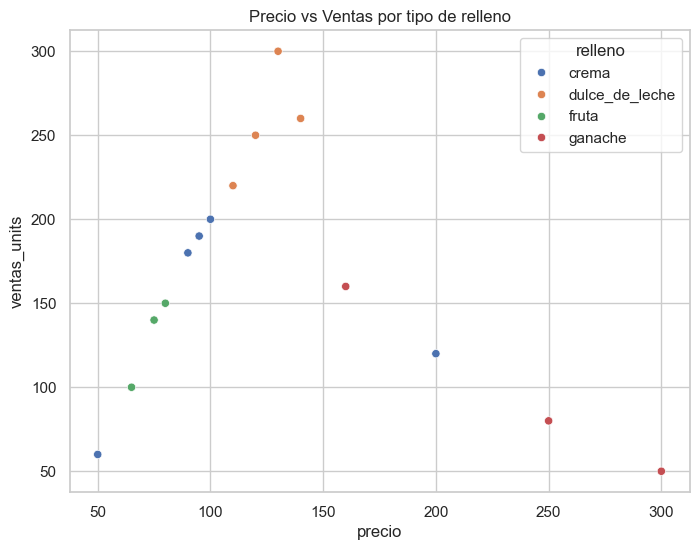

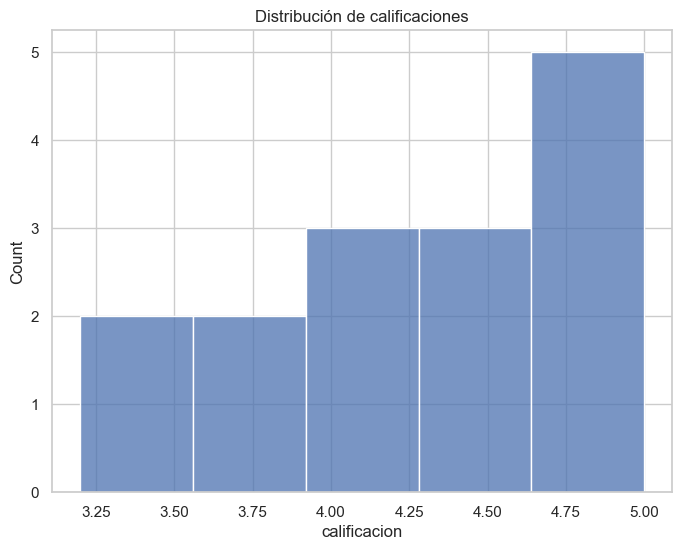

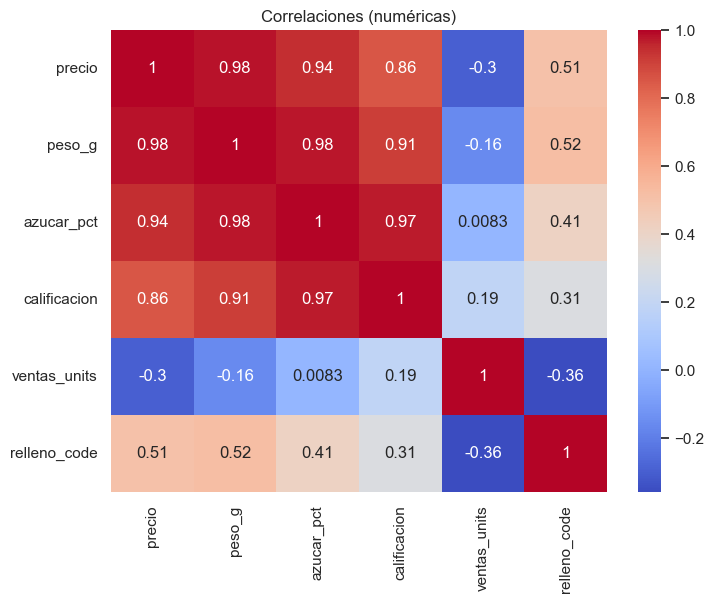

In [3]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='precio', y='ventas_units', hue='relleno')
plt.title('Precio vs Ventas por tipo de relleno')
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(df['calificacion'], bins=5, kde=False)
plt.title('Distribución de calificaciones')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlaciones (numéricas)')
plt.show()

## Modelo predictivo simple (Regresión lineal)
Se intenta predecir `ventas_units` a partir de `precio`, `calificacion` y `peso_g`.

In [4]:
X = df[['precio','calificacion','peso_g']].values
y = df['ventas_units'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('R2 (test):', r2_score(y_test, y_pred))
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print('RMSE (test):', rmse)

# Mostrar coeficientes
coef_names = ['precio','calificacion','peso_g']
for n,c in zip(coef_names, model.coef_):
    print(f'{n}: {c:.4f}')


R2 (test): 0.8797796146071506
RMSE (test): 26.334793491406003
precio: -2.3738
calificacion: 152.8054
peso_g: 4.6124


## Conclusiones (breves)
- Resumen de hallazgos: variables con mayor correlación, desempeño del modelo y recomendaciones para análisis posterior.